# Keep-alive

In [ ]:
%%javascript
function ClickConnect(){
    console.log("Keeping alive");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install and Imports

In [ ]:
!pip install --quiet pillow

import os
import shutil
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.applications import (
    EfficientNetB0, MobileNetV2
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


# Configuration

In [ ]:
# MODEL_TYPE options : 'efficientnet', 'mobilenet'
# CHART_TYPE options : 'candlestick', 'heatmap'
MODEL_TYPE = 'efficientnet'   # <-- CHANGE THIS
CHART_TYPE = 'candlestick'    # <-- CHANGE THIS

# Paths
INDEX_PATH  = '/content/drive/MyDrive/DMIF/chart_index_final.csv'
CHARTS_DIR  = '/content/drive/MyDrive/DMIF/charts_final'
MODELS_DIR  = '/content/drive/MyDrive/DMIF/models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Save path — unique per model+chart combination
SAVE_PATH = f'{MODELS_DIR}/cnn_{MODEL_TYPE}_{CHART_TYPE}.keras'

# Must match training config
IMG_SIZE     = 64
BATCH_SIZE   = 32
CLASS_WEIGHT = {0: 1.0, 1: 1.89}

print(f"Model type  : {MODEL_TYPE}")
print(f"Chart type  : {CHART_TYPE}")
print(f"Save path   : {SAVE_PATH}")
print(f"Image size  : {IMG_SIZE}x{IMG_SIZE}")

Model type  : efficientnet
Chart type  : candlestick
Save path   : /content/drive/MyDrive/DMIF/models/cnn_efficientnet_candlestick.keras
Image size  : 64x64


# Load Chart Index

In [ ]:
index_df = pd.read_csv(INDEX_PATH)

# Filter by chart type
filtered = index_df[index_df['chart_type'] == CHART_TYPE].copy()
filtered = filtered.reset_index(drop=True)

print(f"Total images in index : {len(index_df)}")
print(f"Filtered ({CHART_TYPE}): {len(filtered)}")
print(f"UP   labels : {(filtered['label']==1).sum()} ({(filtered['label']==1).mean()*100:.1f}%)")
print(f"DOWN labels : {(filtered['label']==0).sum()} ({(filtered['label']==0).mean()*100:.1f}%)")

Total images in index : 111104
Filtered (candlestick): 46766
UP   labels : 15921 (34.0%)
DOWN labels : 30845 (66.0%)


# Copy Images to Local Disk

In [ ]:
import zipfile

ZIP_PATH     = f'/content/drive/MyDrive/DMIF/{CHART_TYPE}_images.zip'
LOCAL_ZIP    = f'/content/{CHART_TYPE}_images.zip'
LOCAL_CHARTS = f'/content/charts_local'

# Step 1 — Copy single zip file from Drive (fast)
print(f"Copying {CHART_TYPE} zip from Drive...")
shutil.copy2(ZIP_PATH, LOCAL_ZIP)
print(f"Zip copied")

# Step 2 — Extract
print(f"Extracting images...")
os.makedirs(LOCAL_CHARTS, exist_ok=True)
with zipfile.ZipFile(LOCAL_ZIP, 'r') as z:
    z.extractall(LOCAL_CHARTS)
print(f"Extracted")

# Step 3 — Update paths in filtered dataframe
updated_paths = []
for _, row in filtered.iterrows():
    company    = row['company']
    filename   = row['filename']
    local_path = os.path.join(
        LOCAL_CHARTS, f"{company}_{filename}"
    )
    updated_paths.append(
        local_path if os.path.exists(local_path) else None
    )

filtered['local_path'] = updated_paths
before   = len(filtered)
filtered = filtered[
    filtered['local_path'].notna()
].reset_index(drop=True)

print(f"Usable images: {len(filtered)}")
print(f"Missing      : {before - len(filtered)}")

Copying candlestick zip from Drive...
Zip copied
Extracting images...
Extracted
Usable images: 46766
Missing      : 0


# Corrupt Image Scan

In [ ]:
from PIL import Image

print("Scanning for corrupt images...")
bad_paths = []
for p in filtered['local_path']:
    try:
        img = Image.open(p)
        img.verify()
    except Exception:
        bad_paths.append(p)

if bad_paths:
    print(f"Found {len(bad_paths)} corrupt file(s):")
    for p in bad_paths:
        print(f"  {p}")
    filtered = filtered[~filtered['local_path'].isin(bad_paths)].reset_index(drop=True)
else:
    print("No corrupt images found.")

print(f"Usable images after scan: {len(filtered)}")

Scanning for corrupt images...
No corrupt images found.
Usable images after scan: 46766


# Train/Val/Test Split

In [ ]:
n         = len(filtered)
train_end = int(n * 0.70)
val_end   = int(n * 0.80)

train_df = filtered.iloc[:train_end].reset_index(drop=True)
val_df   = filtered.iloc[train_end:val_end].reset_index(drop=True)
test_df  = filtered.iloc[val_end:].reset_index(drop=True)

print(f"Train : {len(train_df)} | UP: {train_df['label'].mean()*100:.1f}%")
print(f"Val   : {len(val_df)}   | UP: {val_df['label'].mean()*100:.1f}%")
print(f"Test  : {len(test_df)}  | UP: {test_df['label'].mean()*100:.1f}%")

Train : 32736 | UP: 33.5%
Val   : 4676   | UP: 36.0%
Test  : 9354  | UP: 34.9%


# Build tf.data Pipeline

In [ ]:
def parse_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(dataframe, shuffle=False):
    paths  = dataframe['local_path'].values
    labels = dataframe['label'].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df,   shuffle=False)
test_ds  = make_dataset(test_df,  shuffle=False)

print(f"Datasets built")
print(f"  Train batches : {len(train_ds)}")
print(f"  Val batches   : {len(val_ds)}")
print(f"  Test batches  : {len(test_ds)}")

Datasets built
  Train batches : 1023
  Val batches   : 147
  Test batches  : 293


# Load Saved Model\n(skips training entirely — loads the already-trained .keras file)

In [ ]:
print(f"Loading saved model: {SAVE_PATH}")
best_model = tf.keras.models.load_model(SAVE_PATH)
print("Model loaded — skipping training")
best_model.summary()

Loading saved model: /content/drive/MyDrive/DMIF/models/cnn_efficientnet_candlestick.keras
Model loaded — skipping training


Model: "CNN_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 3) │          0 │ input_layer[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 64, 64, 3) │          7 │ rescaling[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 64, 64, 3) │          0 │ normalization[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 65, 65, 3) │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 32, 32,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 32, 32,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 32, 32,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 32, 32,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 32, 32,    │        512 │ block1a_se_excit

 Total params: 7,268,360 (27.73 MB)

 Trainable params: 1,523,249 (5.81 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

 Optimizer params: 3,046,500 (11.62 MB)

# Get Probabilities (train/val/test)

In [ ]:
def get_probs_and_labels(dataset):
    probs, labels = [], []
    for imgs, lbls in dataset:
        p = best_model(imgs, training=False).numpy().flatten()
        probs.extend(p)
        labels.extend(lbls.numpy())
    return np.array(probs), np.array(labels)

print("Running inference on val and test sets...")
va_probs, y_va_true = get_probs_and_labels(val_ds)
te_probs, y_te_true = get_probs_and_labels(test_ds)
print(f"Val samples  : {len(y_va_true)}")
print(f"Test samples : {len(y_te_true)}")

Running inference on val and test sets...
Val samples  : 4676
Test samples : 9354


# Threshold Tuning\n(macro F1 on validation set — balances both classes, avoids collapsing to one class)

In [ ]:
best_thresh, best_macro_f1 = 0.5, 0
for thresh in np.arange(0.30, 0.71, 0.01):
    preds = (va_probs >= thresh).astype(int)
    macro_f1 = f1_score(y_va_true, preds, average='macro')
    if macro_f1 > best_macro_f1:
        best_macro_f1, best_thresh = macro_f1, thresh

default_macro_f1 = f1_score(y_va_true, (va_probs >= 0.5).astype(int), average='macro')

print(f"Best threshold (macro F1) : {best_thresh:.2f}")
print(f"Macro F1 at best threshold: {best_macro_f1:.4f}")
print(f"Macro F1 at default 0.5   : {default_macro_f1:.4f}")

Best threshold (macro F1) : 0.50
Macro F1 at best threshold: 0.3904
Macro F1 at default 0.5   : 0.3904


# Evaluate — Full Metrics

In [ ]:
va_preds = (va_probs >= best_thresh).astype(int)
te_preds = (te_probs >= best_thresh).astype(int)

va_acc = accuracy_score(y_va_true, va_preds)
te_acc = accuracy_score(y_te_true, te_preds)

precision = precision_score(y_te_true, te_preds)
recall    = recall_score(y_te_true, te_preds)
f1        = f1_score(y_te_true, te_preds)
roc_auc   = roc_auc_score(y_te_true, te_probs)
cm        = confusion_matrix(y_te_true, te_preds)

print(f"\n{'='*55}")
print(f"MODEL : {MODEL_TYPE.upper()} — {CHART_TYPE.upper()}")
print(f"{'='*55}")
print(f"Val  Accuracy  : {va_acc:.4f}")
print(f"Test Accuracy  : {te_acc:.4f}")
print(f"Precision (UP) : {precision:.4f}")
print(f"Recall    (UP) : {recall:.4f}")
print(f"F1-Score  (UP) : {f1:.4f}")
print(f"ROC-AUC        : {roc_auc:.4f}")
print(f"\nTest Classification Report:")
print(classification_report(y_te_true, te_preds, target_names=['DOWN', 'UP']))
print(f"Confusion Matrix:")
print(cm)
print(f"{'='*55}")


MODEL : EFFICIENTNET — CANDLESTICK
Val  Accuracy  : 0.6403
Test Accuracy  : 0.6513
Precision (UP) : 0.0000
Recall    (UP) : 0.0000
F1-Score  (UP) : 0.0000
ROC-AUC        : 0.5258

Test Classification Report:
              precision    recall  f1-score   support

        DOWN       0.65      1.00      0.79      6092
          UP       0.00      0.00      0.00      3262

    accuracy                           0.65      9354
   macro avg       0.33      0.50      0.39      9354
weighted avg       0.42      0.65      0.51      9354

Confusion Matrix:
[[6092    0]
 [3262    0]]


# Confusion Matrix Plot

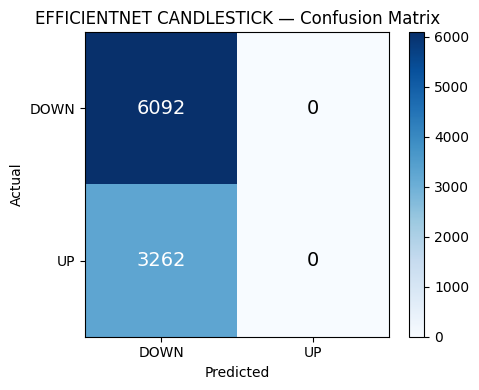

Saved: /content/drive/MyDrive/DMIF/models/cnn_efficientnet_candlestick_confusion_matrix.png


In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

ax.set_xticks([0, 1]); ax.set_xticklabels(['DOWN', 'UP'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['DOWN', 'UP'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'{MODEL_TYPE.upper()} {CHART_TYPE.upper()} — Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()

cm_path = f'{MODELS_DIR}/cnn_{MODEL_TYPE}_{CHART_TYPE}_confusion_matrix.png'
plt.savefig(cm_path)
plt.show()
print(f"Saved: {cm_path}")

# Save Results Summary

In [ ]:
results = {
    'model_type'        : MODEL_TYPE,
    'chart_type'        : CHART_TYPE,
    'val_accuracy'      : float(va_acc),
    'test_accuracy'     : float(te_acc),
    'precision_up'      : float(precision),
    'recall_up'         : float(recall),
    'f1_score_up'       : float(f1),
    'roc_auc'           : float(roc_auc),
    'confusion_matrix'  : cm.tolist(),
    'default_threshold_results': {
        'accuracy': float(accuracy_score(y_te_true, (te_probs >= 0.5).astype(int)))
    },
    'best_threshold'    : float(best_thresh),
    'best_threshold_macro_f1_val': float(best_macro_f1),
    'train_samples'     : len(train_df),
    'val_samples'       : len(val_df),
    'test_samples'      : len(test_df),
    'img_size'          : IMG_SIZE,
    'class_weight'      : CLASS_WEIGHT
}

results_path = f'{MODELS_DIR}/cnn_{MODEL_TYPE}_{CHART_TYPE}_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved: {results_path}")
print(json.dumps(results, indent=2))

Results saved: /content/drive/MyDrive/DMIF/models/cnn_efficientnet_candlestick_results.json
{
  "model_type": "efficientnet",
  "chart_type": "candlestick",
  "val_accuracy": 0.6402908468776732,
  "test_accuracy": 0.6512721830233056,
  "precision_up": 0.0,
  "recall_up": 0.0,
  "f1_score_up": 0.0,
  "roc_auc": 0.525847816617707,
  "confusion_matrix": [
    [
      6092,
      0
    ],
    [
      3262,
      0
    ]
  ],
  "default_threshold_results": {
    "accuracy": 0.6512721830233056
  },
  "best_threshold": 0.5000000000000002,
  "best_threshold_macro_f1_val": 0.3903520208604954,
  "train_samples": 32736,
  "val_samples": 4676,
  "test_samples": 9354,
  "img_size": 64,
  "class_weight": {
    "0": 1.0,
    "1": 1.89
  }
}
